In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Задача 1: Построение параметрически заданной кривой

**Построить параметрически заданную кривую. Добавить линии сетки, подписи осей и заголовок графика, в котором вывести название кривой. Для построения графиков использовать модуль `matplotlib.pyplot`.**

### Гиперэллипс:

$$
\begin{cases}
x(t) = \operatorname{sgn}(\cos t) \cdot |\cos t|^{1/2} \\
y(t) = \operatorname{sgn}(\sin t) \cdot |\sin t|^{1/2}
\end{cases}, \quad t \in [0, 2\pi]
$$

где $\operatorname{sgn}$ — функция знака числа.

In [2]:
def x(t):
    return np.sign(np.cos(t)) * (np.abs(np.cos(t)) ** (1/2))

In [3]:
def y(t):
    return np.sign(np.sin(t)) * (np.abs(np.sin(t)) ** (1/2))

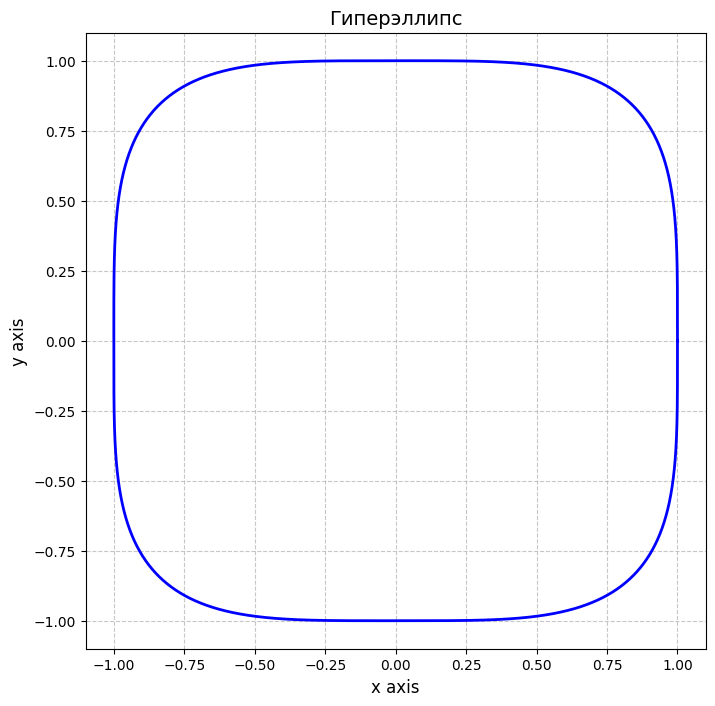

In [12]:
t = np.linspace(0, 2*np.pi, 1000)

plt.figure(figsize=(8, 8))

plt.title('Гиперэллипс', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)

plt.xlabel('x axis', fontsize=12)
plt.ylabel('y axis', fontsize=12)

plt.plot(x(t), y(t), 'b-', linewidth=2, label=f'Гиперэллипс')

## Задача 2

Построить графики функций $y(x)$ и $z(x)$ на одних и тех же осях координат, используя различные типы и цвета линий, маркеры. Добавить легенду.

$P_n$, $T_n$, $H_n$, $L_n$ — многочлены Лежандра, Чебышева, Эрмита и Лагерра соответственно; для работы с ними использовать модуль `numpy.polynomial`.

**Вариант 17.3**

$$
y(x) = P_8(x), \qquad z(x) =
\begin{cases}
e^{x^3}, & x \le 0 \\
1, & x > 0
\end{cases}
$$

$$
x \in [-1;\, 1]
$$

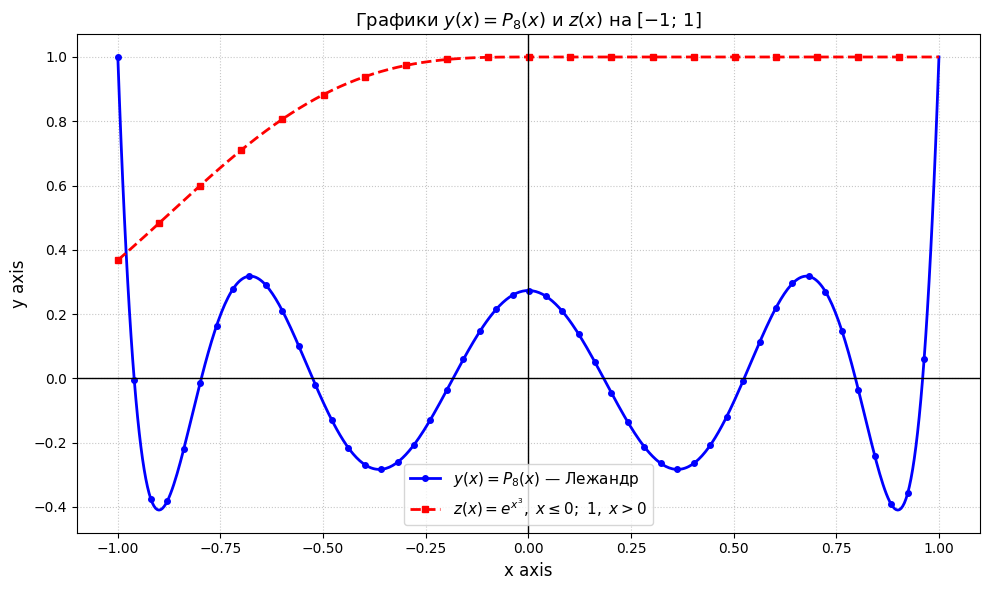

In [21]:
x = np.linspace(-1, 1, 500)

# Многочлен Лежандра P_8(x) 
coef = np.zeros(9)
coef[8] = 1                      # P_8(x)
y = np.polynomial.legendre.legval(x, coef)

z = np.where(x <= 0, np.exp(x**3), 1.0)

plt.figure(figsize=(10, 6))

plt.plot(x, y, color='blue', linestyle='-', linewidth=2,
         marker='o', markevery=10, markersize=4,
         label=r'$y(x) = P_8(x)$ — Лежандр')

plt.plot(x, z, color='red', linestyle='--', linewidth=2,
         marker='s', markevery=25, markersize=4,
         label=r'$z(x) = e^{x^3},\ x\leq0;\ 1,\ x > 0$')

plt.grid(True, linestyle=':', alpha=0.7)

plt.xlabel('x axis', fontsize=12)
plt.ylabel('y axis', fontsize=12)

plt.title(r'Графики $y(x)=P_8(x)$ и $z(x)$ на $[-1;\,1]$', fontsize=13)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Задание 3

Написать функцию, принимающую в качестве аргумента число `N` (размерность квадратной матрицы `A`), и с помощью модуля `scipy.sparse` формирующую **разреженную** матрицу `A` из задания 1 лабораторной 2.

Матрица должна создаваться **сразу в разреженном формате**, без создания промежуточной плотной матрицы.

Затем с помощью функций из модуля `scipy.sparse.linalg` выполнить для разреженной матрицы `A` задание 2 из лабораторной 2.

$$ \quad A = \begin{pmatrix}
-7 & 0 & 4 & 0 & 0 & 0 & 0 \\
0 & -4 & 0 & 4 & 0 & 0 & 0 \\
0 & 0 & -1 & 0 & 4 & 0 & 0 \\
0 & 0 & 0 & 2 & 0 & 4 & 0 \\
0 & 0 & 0 & 0 & 5 & 0 & 4 \\
8 & 8 & 8 & 8 & 8 & 8 & 8 \\
0 & 0 & 0 & 0 & 0 & 0 & 11
\end{pmatrix} $$

## Задание 2 Лаба 2
Найти число обусловленности матрицы А в октаэдрической
норме. Решить систему линейных уравнений Ax = b, где b = (1, 1, …, 1)T. Вывести
октаэдрическую норму решения. Если матрица А вырожденная, выводить
сообщение об этом.

In [23]:
from scipy import sparse
from scipy.sparse import linalg

In [ ]:
def matrix(N : int) -> np.ndarray: # Функция для создания матрицы из задания 1 лабы 2
    A = np.zeros((N, N), dtype=np.int16)

    main_diag = np.arange(-7, -7 + 3 * N, 3)
    A += np.diag(main_diag)

    A += np.diag(np.ones(N-2, dtype=np.int16) * 4, 2)

    A[-2, :] = 8

    # np.savetxt('Lab2.txt', A, fmt='%d', delimiter='\t') 

    return A

In [47]:
def build_sparse_matrix(N):

    main_diag = np.arange(-7, -7 + 3 * N, 3)

    off_diag = np.ones(N-2) * 4

    

    # Формирование разреженной матрицы 
    A = sparse.diags(
        diagonals=[main_diag, off_diag],
        offsets=[0, 2],
        shape=(N, N),
        format='csc'          # разреженный формат List of Lists
    )

    A[-2, :] = 8

    return A


Возьмём матрицу

$$
A =
\begin{bmatrix}
1 & 0 & 0 & 2 \\
0 & 0 & 3 & 0 \\
0 & 4 & 0 & 5
\end{bmatrix}
$$

В формате `lil` она выглядит так:

```text
A.rows = [ [0, 3],       # строка 0: ненулевые в столбцах 0 и 3
           [2],          # строка 1: ненулевой в столбце 2
           [1, 3] ]      # строка 2: ненулевые в столбцах 1 и 3

A.data = [ [1, 2],       # строка 0: значения 1 и 2
           [3],          # строка 1: значение 3
           [4, 5] ]      # строка 2: значения 4 и 5
```

**Чтение:** `A[0, 0] = 1`, `A[0, 3] = 2`, `A[1, 2] = 3`, `A[2, 1] = 4`, `A[2, 3] = 5`.

In [48]:
B = build_sparse_matrix(7)

B.toarray()

c:\Users\LENOVOL\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


array([[-7.,  0.,  4.,  0.,  0.,  0.,  0.],
       [ 0., -4.,  0.,  4.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  0.,  4.,  0.,  0.],
       [ 0.,  0.,  0.,  2.,  0.,  4.,  0.],
       [ 0.,  0.,  0.,  0.,  5.,  0.,  4.],
       [ 8.,  8.,  8.,  8.,  8.,  8.,  8.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 11.]])

In [49]:
def task2_sparse(A):
    """
    1. Проверка вырожденности (det == 0).
    2. Число обусловленности в октаэдрической норме.
    3. Решение СЛАУ Ax = b, b = (1, ..., 1)^T.
    4. Октаэдрическая норма решения ||x||_∞.
    через scipy.sparse.linalg
    """
    N = A.shape[0]

    # 1. Определитель через LU-разложение (splu) 
    lu  = sparse.linalg.splu(A.tocsc())           # splu требует CSC
    det = lu.U.diagonal().prod()

    if np.isclose(det, 0.0):
        print("Матрица A вырожденная (det ≈ 0). Решение невозможно.")
        return None

    # 2. Число обусловленности в октаэдрической норме 
    #   ||A||_∞ = max_i Σ_j |a_ij|
    norm_A = np.max(np.asarray(np.abs(A).sum(axis=1)).ravel())

    #   ||A^(-1)||_∞ через разреженную обратную
    Ainv      = sparse.linalg.inv(A).tocsr()
    norm_Ainv = np.max(np.asarray(np.abs(Ainv).sum(axis=1)).ravel())

    cond_inf = norm_A * norm_Ainv

    # 3. Решение СЛАУ Ax = b
    b = np.ones(N)
    x = sparse.linalg.spsolve(A, b)

    # 4. Октаэдрическая норма решения 
    norm_x = np.max(np.abs(x))          

    print("=" * 60)
    print(f"N = {N}, формат = {A.format}, nnz = {A.nnz}")
    print("-" * 60)
    print(f"det(A)                       = {det:.6g}")
    print(f"||A||_∞                      = {norm_A:.6g}")
    print(f"||A^(-1)||_∞                 = {norm_Ainv:.6g}")
    print(f"Число обусловленности        = {cond_inf:.6g}")
    print("-" * 60)
    print(f"||x||_∞ (октаэдр. норма)     = {norm_x:.6g}")
    print(f"x[:5]                        = {x[:5]}")
    print("=" * 60)
    
    return None

In [50]:
task2_sparse(B)

N = 7, формат = csc, nnz = 18
------------------------------------------------------------
det(A)                       = 73920
||A||_∞                      = 56
||A^(-1)||_∞                 = 2.82359
Число обусловленности        = 158.121
------------------------------------------------------------
||x||_∞ (октаэдр. норма)     = 0.547403
x[:5]                        = [-0.42337662  0.2974026  -0.49090909  0.5474026   0.12727273]


## Задание 4

На указанном отрезке найти **минимальное** значение функции $F(a)$. Использовать функции из модуля `scipy.special` ($J_n$, $I_n$, $K_n$ — функции Бесселя, $P_n$ — многочлен Лежандра, $T_n$ — многочлен Чебышёва, $L_n$ — многочлен Лагерра, $H_n$ — многочлен Эрмита).

**Вариант 17**

$$
F(a) = \int_{3}^{6} J_3(ax)\, T_3(x/a)\, dx, \qquad a \in [3;\, 8].
$$


Отрезок              : [3.0; 8.0]
Точка минимума a*    : 3.695696
Минимум F(a*)        : -0.583235


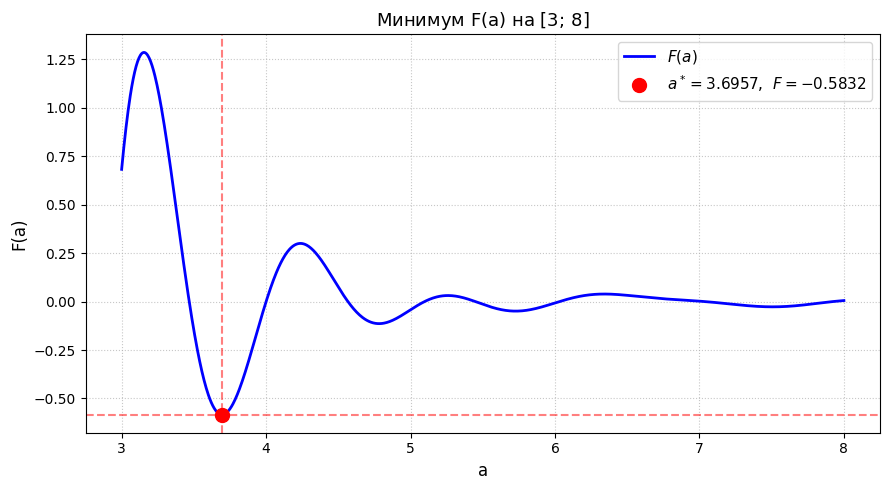

In [59]:
from scipy import special
from scipy.integrate import quad
from scipy.optimize import minimize_scalar


#  Подынтегральная функция
def integrand(x, a):
    return special.jv(3, a * x) * special.eval_chebyt(3, x / a)

def F(a):
    val, _ = quad(integrand, 3, 6, args=(a,))
    return val


#  Поиск минимума на отрезке [3; 8]
a_min, a_max = 3.0, 8.0

a = np.linspace(a_min, a_max, 1000)
y = np.array([F(ai) for ai in a])

#res = minimize_scalar(F, bounds=(a_min, a_max), method='bounded')
#a_star = res.x
#F_min  = res.fun

a_star = a[np.argmin(y)]
F_min = y[np.argmin(y)]

print("=" * 55)
print(f"Отрезок              : [{a_min}; {a_max}]")
print(f"Точка минимума a*    : {a_star:.6f}")
print(f"Минимум F(a*)        : {F_min:.6f}")
print("=" * 55)


# График


plt.figure(figsize=(9, 5))

plt.plot(a, y, 'b-', linewidth=2, label=r'$F(a)$')

plt.plot(a_star, F_min, 'ro', markersize=10,
         label=fr'$a^*={a_star:.4f}$,  $F={F_min:.4f}$')
plt.axvline(a_star, color='r', linestyle='--', alpha=0.5)
plt.axhline(F_min,   color='r', linestyle='--', alpha=0.5)

plt.grid(True, linestyle=':', alpha=0.7)

plt.xlabel('a', fontsize=12)
plt.ylabel('F(a)', fontsize=12)

plt.title(r'Минимум F(a) на $[3;\,8]$',
          fontsize=13)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

## Задание 5

Для указанной в варианте функции найти точку **локального минимума**. Если локальных минимумов несколько, достаточно найти только **один** из них. Построить график минимизируемой функции в виде **поверхности** таким образом, чтобы был виден искомый локальный минимум. Построить аналогичный **контурный** график (`contour`).

**Вариант 17**

$$
f(x, y) = 7x^2 + 4y^2 + 2y + 3x + 7.
$$

Точка минимума: x* = -0.214286, y* = -0.250000
Минимум f(x*, y*) = 6.428571
Успех: True


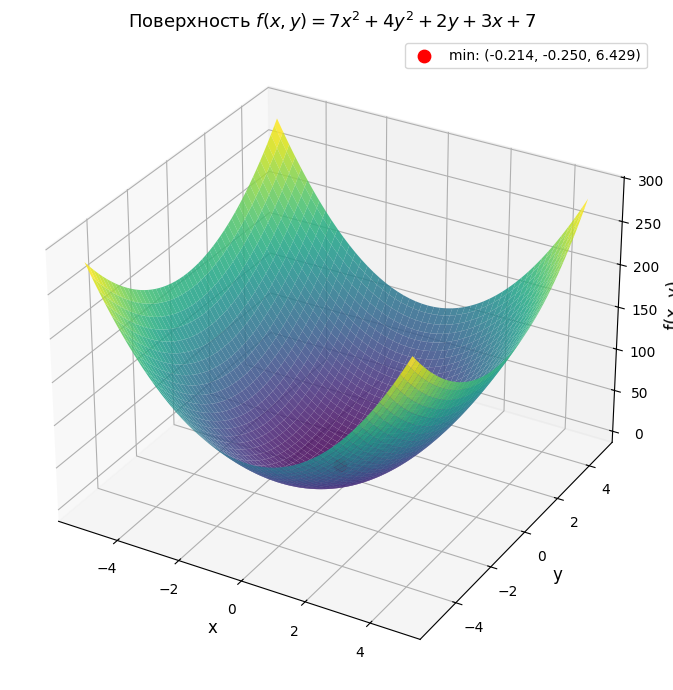

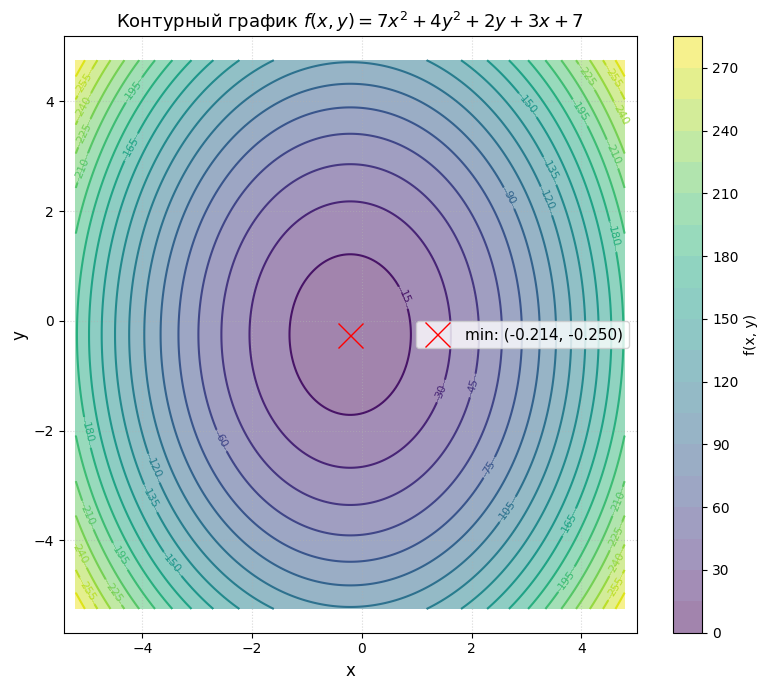

In [75]:
from scipy.optimize import minimize


#  Функция
def f(xy):
    x, y = xy
    return 7*x**2 + 4*y**2 + 2*y + 3*x + 7


#  Поиск минимума
x0 = np.array([0.0, 0.0])          # начальная точка
res = minimize(f, x0)              # метод BFGS по умолчанию

x_star, y_star = res.x
f_min = res.fun

print("=" * 55)
print(f"Точка минимума: x* = {x_star:.6f}, y* = {y_star:.6f}")
print(f"Минимум f(x*, y*) = {f_min:.6f}")
print(f"Успех: {res.success}")
print("=" * 55)


#  Сетка для графиков

SCALE = 5

x = np.linspace(x_star - SCALE, x_star + SCALE, 200)
y = np.linspace(y_star - SCALE, y_star + SCALE, 200)
X, Y = np.meshgrid(x, y)
Z = 7*X**2 + 4*Y**2 + 2*Y + 3*X + 7


#  Поверхность
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85,
                edgecolor='none', rstride=4, cstride=4)

# Точка минимума
ax.scatter(x_star, y_star, f_min, color='red', s=80,
           label=f'min: ({x_star:.3f}, {y_star:.3f}, {f_min:.3f})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('f(x, y)', fontsize=12)
ax.set_title(r'Поверхность $f(x,y)=7x^2+4y^2+2y+3x+7$', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# Контурный график
plt.figure(figsize=(8, 7))

cs = plt.contour(X, Y, Z, levels=25, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=8)

# Точка минимума
plt.plot(x_star, y_star, 'x', color='red', markersize=18,
         label=f'min: ({x_star:.3f}, {y_star:.3f})')

# Заливка
plt.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.5)

plt.colorbar(label='f(x, y)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(r'Контурный график $f(x,y)=7x^2+4y^2+2y+3x+7$', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axis('equal')
plt.tight_layout()
plt.show()